# Лабораторная работа №2: Прогнозирование временных рядов
**Задача:** Прогноз температуры на 7 дней вперед (многошаговый прогноз).

В этом шаблоне реализованы основные этапы согласно ТЗ и лекционным материалам.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from scipy.fft import fft, fftfreq
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import lightgbm as lgb
import optuna

warnings.filterwarnings('ignore')
# Настройка визуального стиля
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

## 1. Загрузка данных
- Исползование `pd.ExcelFile`, чтобы увидеть скрытые листы.
- Загрузка только валидных листов, содержащих temperature_2m

In [2]:
file_path = 'weather_data.xlsx'

# Получение списка всех листов
xl = pd.ExcelFile(file_path, engine='openpyxl')
print(f"Найдено листов в файле: {xl.sheet_names}")

dfs = {}
valid_sheets = []
skipped_sheets = []

# Проход по всем листам и проверяем наличие ключевого столбца
for sheet_name in xl.sheet_names:
    
    df_sheet = pd.read_excel(file_path, sheet_name=sheet_name, engine='openpyxl')
    
    # Удаляем полностью пустые строки и столбцы
    df_sheet = df_sheet.dropna(how='all', axis=1).dropna(how='all', axis=0)
    
    # Приведение названия колонок к нижнему регистру для корректной проверки
    df_sheet.columns = (
        df_sheet.columns
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(' ', '_')
    )
    
    # Проверка наличия ключевого признака
    if 'temperature_2m' in df_sheet.columns:
        df_sheet['_source_sheet'] = sheet_name
        dfs[sheet_name] = df_sheet
        valid_sheets.append(sheet_name)
    else:
        skipped_sheets.append(sheet_name)

# Отчёт о фильтрации
print("\nЛисты с погодными данными (будут объединены):")
print(valid_sheets)

print("\nПропущенные листы (нет temperature_2m):")
print(skipped_sheets)

# Объединяем только валидные листы
if len(dfs) == 0:
    raise ValueError("Не найдено ни одного листа с колонкой 'temperature_2m'")

df_raw = pd.concat(dfs.values(), ignore_index=True)

print(f"\nРазмер объединённого датафрейма: {df_raw.shape}")
print(f"Количество использованных листов: {len(valid_sheets)}")

Найдено листов в файле: ['Ëèñò1', 'Лист1', 'ÌÀÈ', 'ýòî', 'ÿ', '!', 'Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû', 'Ëèñò3_ñìåøàííûå_òèïû']

Листы с погодными данными (будут объединены):
['Ëèñò1', 'Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû', 'Ëèñò3_ñìåøàííûå_òèïû']

Пропущенные листы (нет temperature_2m):
['Лист1', 'ÌÀÈ', 'ýòî', 'ÿ', '!']

Размер объединённого датафрейма: (370577, 25)
Количество использованных листов: 3


## 2. Очистка и предобработка

### Работа с кодировками, ошибочными строками, опечатками

In [3]:
# 2. Восстановление кодировки и исправление опечаток в городах
def fix_encoding(text):
    try:
        return str(text).encode('latin1').decode('cp1251')
    except:
        return str(text)

target_cols = [
    'ds',
    'city',
    'temperature_2m',
    'relative_humidity_2m',
    'precipitation',
    'rain',
    'snowfall',
    'wind_speed_10m',
    'surface_pressure',
    'weathercode'
]

existing_cols = [c for c in target_cols if c in df_raw.columns]
df = df_raw[existing_cols].copy()

print(f"Колонки, которые будут использоваться дальше: {existing_cols}")

# Сохранение исходное значение города для аудита
df['city_raw'] = df['city']

# Исправление кодировки
df['city_decoded'] = df['city_raw'].apply(fix_encoding)

# Нормализация для дальнейшего маппинга
df['city_normalized'] = (
    df['city_decoded']
    .astype('string')
    .str.lower()
    .str.strip()
)

print("\nГорода после расшифровки, но ДО исправления опечаток:")
display(
    df[['city_raw', 'city_decoded', 'city_normalized']]
    .drop_duplicates()
    .sort_values('city_normalized')
)

# Словарь исправления опечаток
city_mapping = {
    'геленджик': 'Геленджик',
    'геленджикк': 'Геленджик',
    'геленджи': 'Геленджик',

    'благовещенск': 'Благовещенск',
    'благовещенс': 'Благовещенск',
    'благовещенскк': 'Благовещенск',

    'москва': 'Москва',
    'мосва': 'Москва',

    'санкт-петербург': 'Санкт-Петербург',

    'находка': 'Находка',

    'сочи': 'Сочи',
    'сычи': 'Сочи',
    'счи': 'Сочи',
    'соч': 'Сочи'
}

# Применение исправления городов
df['city_clean'] = df['city_normalized'].map(city_mapping)

# Строки, которые не удалось сопоставить
unmapped_cities = (
    df[df['city_clean'].isna()]
    [['city_raw', 'city_decoded', 'city_normalized']]
    .drop_duplicates()
)

print("\nЗначения городов, которые НЕ удалось сопоставить:")
display(unmapped_cities)

# Удаление строк без города
before_rows = len(df)
df = df.dropna(subset=['city_clean']).copy()
after_rows = len(df)

print(f"\nУдалено строк без корректного города: {before_rows - after_rows}")

# Замена рабочей колонки city на очищенную
df['city'] = df['city_clean']

print("\n Города после полной очистки:")
display(
    df['city']
    .value_counts()
    .rename_axis('city')
    .reset_index(name='rows_count')
)

Колонки, которые будут использоваться дальше: ['ds', 'city', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'wind_speed_10m', 'surface_pressure', 'weathercode']

Города после расшифровки, но ДО исправления опечаток:


,city_raw,city_decoded,city_normalized
125168,NaN,nan,nan
296,Áëàãîâåùåíñ,Благовещенс,благовещенс
1,Áëàãîâåùåíñê,Благовещенск,благовещенск
173,ÁËÀÃÎÂÅÙÅÍÑÊ,БЛАГОВЕЩЕНСК,благовещенск
674,áëàãîâåùåíñê,благовещенск,благовещенск
351,Áëàãîâåùåíñêê,Благовещенскк,благовещенскк
2114,Ãåëåíäæè,Геленджи,геленджи
0,Ãåëåíäæèê,Геленджик,геленджик
809,ÃÅËÅÍÄÆÈÊ,ГЕЛЕНДЖИК,геленджик
1103,ãåëåíäæèê,геленджик,геленджик



Значения городов, которые НЕ удалось сопоставить:


,city_raw,city_decoded,city_normalized
125168,NaN,nan,nan



Удалено строк без корректного города: 35

 Города после полной очистки:


,city,rows_count
0,Благовещенск,62599
1,Геленджик,62525
2,Санкт-Петербург,61368
3,Сочи,61368
4,Москва,61365
5,Находка,61317


### Работа с типами данных, очистка выбросов, интерполяция для пропусков

Пропуски ДО обработки выбросов и интерполяции:
city                    0
ds                      0
temperature_2m          0
relative_humidity_2m    0
precipitation           0
wind_speed_10m          0
surface_pressure        0
dtype: int64
Найденные выбросы:
        ds            city  temp_before_outliers
2024-01-13          Москва            -27.941667
2024-01-03 Санкт-Петербург            -27.412500
2024-01-04 Санкт-Петербург            -26.869565
2024-01-04          Москва            -26.690909
2024-01-03          Москва            -26.175000
2024-01-05 Санкт-Петербург            -22.954167
2024-01-02 Санкт-Петербург            -22.866666

Всего найдено и удалено выбросов: 7


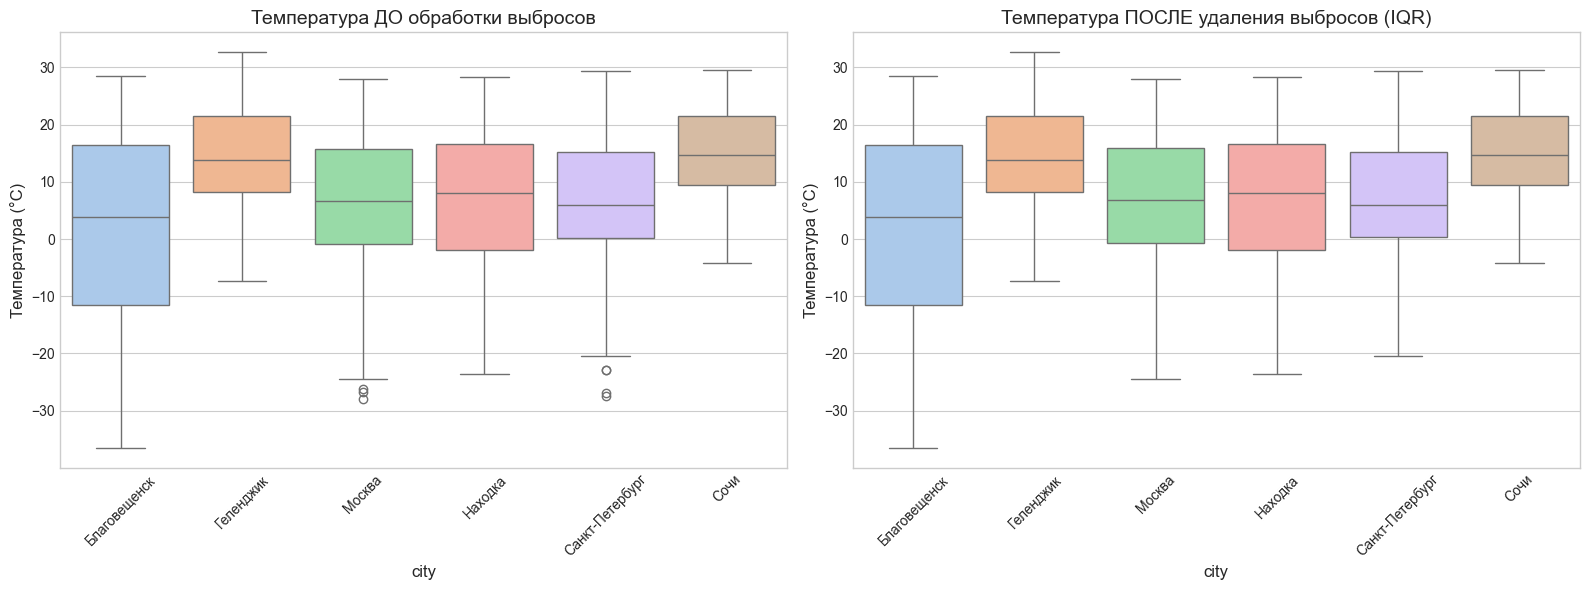

Пропуски ПОСЛЕ удаления выбросов:
Найдено и удалено выбросов: 7
city                    0
ds                      0
temperature_2m          7
relative_humidity_2m    0
precipitation           0
wind_speed_10m          0
surface_pressure        0
temp_before_outliers    0
dtype: int64
Пропуски ПОСЛЕ интерполяции
city                    0
ds                      0
temperature_2m          0
relative_humidity_2m    0
precipitation           0
wind_speed_10m          0
surface_pressure        0
dtype: int64
Обработанный датафрейм: (15342, 7)


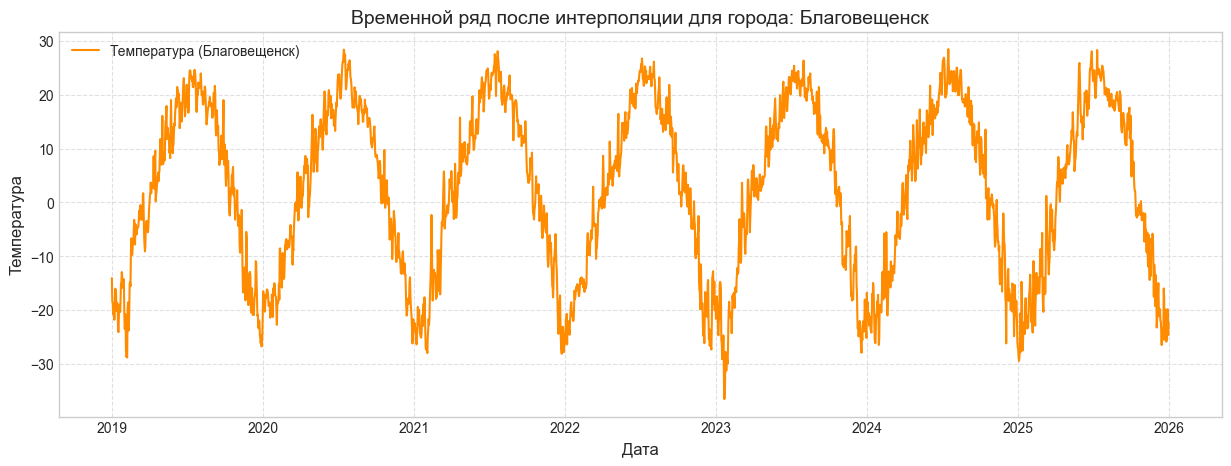

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df['ds'] = pd.to_datetime(df['ds'])

agg_dict = {
    'temperature_2m': 'mean', 'relative_humidity_2m': 'mean',
    'precipitation': 'sum', 'wind_speed_10m': 'mean', 
    'surface_pressure': 'mean'
}
agg_dict = {k: v for k, v in agg_dict.items() if k in df.columns}
cols_to_numeric = list(agg_dict.keys())
df[cols_to_numeric] = df[cols_to_numeric].apply(pd.to_numeric, errors='coerce')

# Приведение к единому временному индексу (Дневная частота)
df_daily = df.set_index('ds').groupby('city').resample('D').agg(agg_dict).reset_index()


#  1. Пропуски ДО обработки
print("Пропуски ДО обработки выбросов и интерполяции:")
print(df_daily.isna().sum())


df_daily['temp_before_outliers'] = df_daily['temperature_2m'].copy()


# 2. Обработка выбросов (IQR) для целевой переменной
def remove_outliers_iqr(series, multiplier=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    return series.where((series >= lower_bound) & (series <= upper_bound), np.nan)


# Применение IQR
df_daily['temperature_2m'] = df_daily.groupby('city')['temperature_2m'].transform(remove_outliers_iqr)


# 3. Вывод строк с аномалиями

outliers_mask = df_daily['temp_before_outliers'].notna() & df_daily['temperature_2m'].isna()
outliers_df = df_daily[outliers_mask]

print("Найденные выбросы:")
if not outliers_df.empty:
    display_cols = ['ds', 'city', 'temp_before_outliers']
    outliers_df_sorted = outliers_df[display_cols].sort_values(by='temp_before_outliers')

    print(outliers_df_sorted.to_string(index=False))
    print(f"\nВсего найдено и удалено выбросов: {len(outliers_df)}")
else:
    print("Выбросов не найдено.")



# 4. Графики
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График ДО
sns.boxplot(data=df_daily, x='city', y='temp_before_outliers', ax=axes[0], palette='pastel')
axes[0].set_title('Температура ДО обработки выбросов', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Температура (°C)')

# График ПОСЛЕ
sns.boxplot(data=df_daily, x='city', y='temperature_2m', ax=axes[1], palette='pastel')
axes[1].set_title('Температура ПОСЛЕ удаления выбросов (IQR)', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Температура (°C)')

plt.tight_layout()
plt.show()

# 5. Пропуски ПОСЛЕ IQR
print("Пропуски ПОСЛЕ удаления выбросов:")
outliers_found = df_daily['temperature_2m'].isna().sum() - df_daily['temp_before_outliers'].isna().sum()
print(f"Найдено и удалено выбросов: {outliers_found}")
print(df_daily.isna().sum())
print("="*50)


# 6. Заполнение пропусков (Интерполяция внутри города)
def interpolate_group(group):
    return group.interpolate(method='linear').bfill().ffill()

df_daily[cols_to_numeric] = df_daily.groupby('city', group_keys=False)[cols_to_numeric].apply(interpolate_group)

df_daily = df_daily.drop(columns=['temp_before_outliers'])

# 7. Пропуски ПОСЛЕ интерполяции
print("Пропуски ПОСЛЕ интерполяции")
print(df_daily.isna().sum())
print("="*50)
print(f"Обработанный датафрейм: {df_daily.shape}")


# График временного ряда для одного города
sample_city = df_daily['city'].iloc[0]
city_data = df_daily[df_daily['city'] == sample_city]

plt.figure(figsize=(15, 5))
plt.plot(city_data['ds'], city_data['temperature_2m'], label=f'Температура ({sample_city})', color='darkorange')
plt.title(f'Временной ряд после интерполяции для города: {sample_city}', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Температура')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

## 3. Анализ (EDA)
Проверка стационарности и декомпозиция.

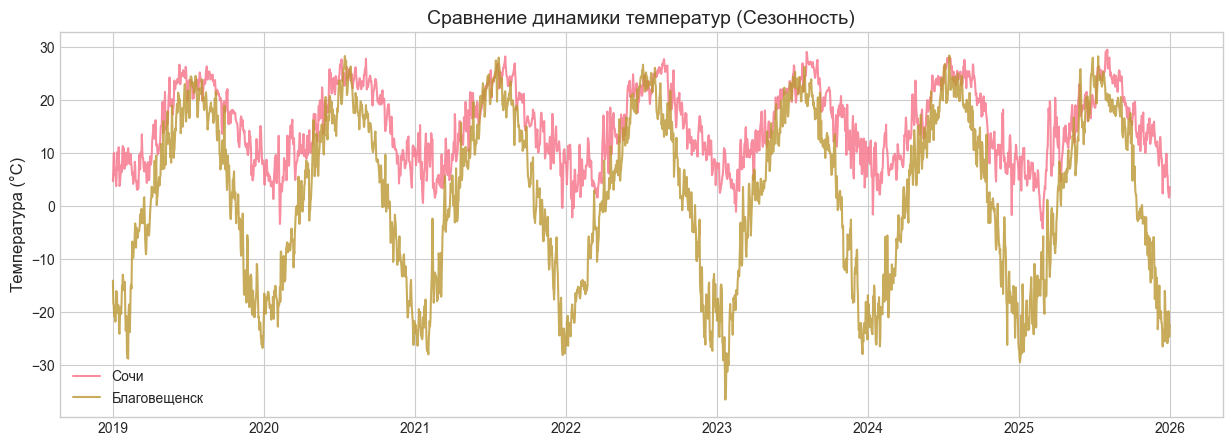

Тест Дики-Фуллера (Москва)
p-value: 0.02190 -> Ряд стационарен

ADF может показать стационарность из-за длинной выборки.


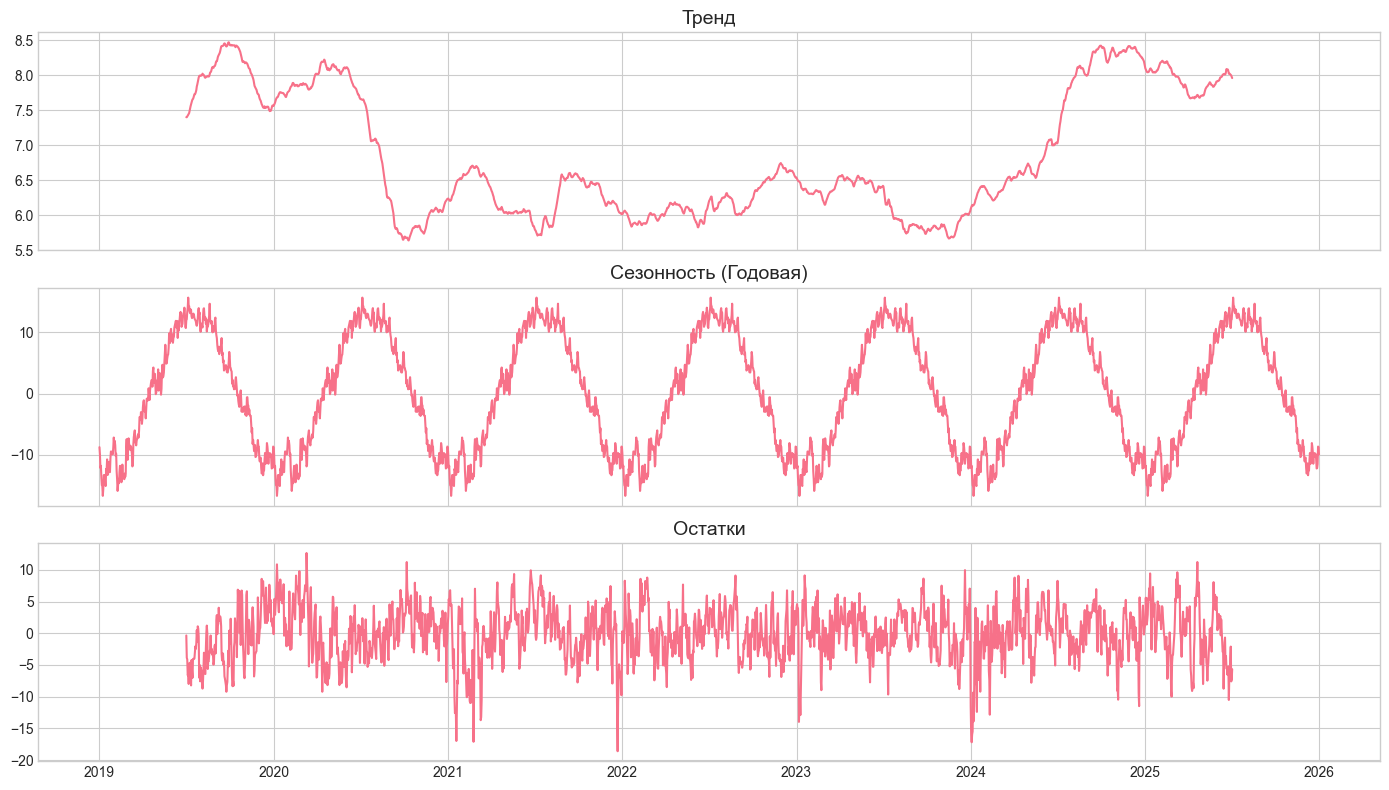

Проверка Автокорреляции (Москва)


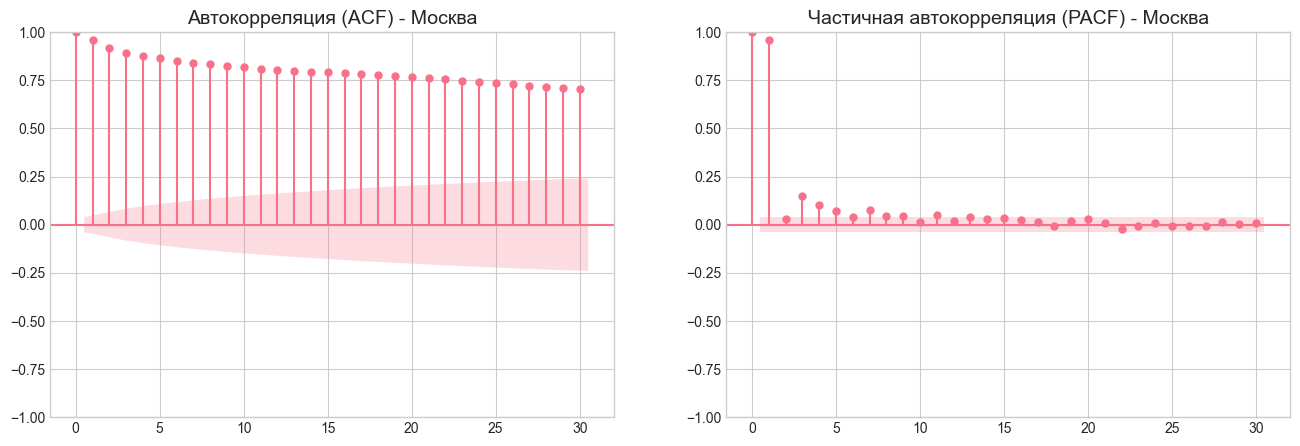

Проверка годовой автокорреляции


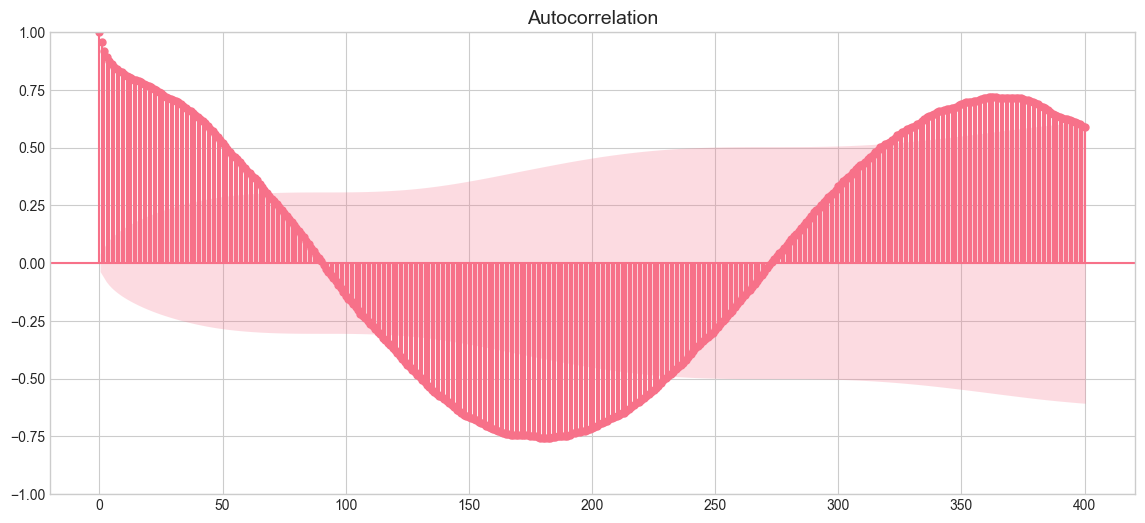

In [5]:
city_1, city_2 = 'Сочи', 'Благовещенск'

plt.figure(figsize=(15, 5))
plt.plot(df_daily[df_daily['city']==city_1]['ds'], df_daily[df_daily['city']==city_1]['temperature_2m'], label=city_1, alpha=0.8)
plt.plot(df_daily[df_daily['city']==city_2]['ds'], df_daily[df_daily['city']==city_2]['temperature_2m'], label=city_2, alpha=0.8)
plt.title('Сравнение динамики температур (Сезонность)')
plt.ylabel('Температура (°C)')
plt.legend()
plt.show()

# Декомпозиция и FFT для одного города (Москва)
sample_city = 'Москва'
df_sample = df_daily[df_daily['city'] == sample_city].set_index('ds')

print(f"Тест Дики-Фуллера ({sample_city})")
adf_result = adfuller(df_sample['temperature_2m'])
print(f"p-value: {adf_result[1]:.5f} -> Ряд {'стационарен' if adf_result[1] < 0.05 else 'нестационарен'}\n")
if adf_result[1] < 0.05:
    print("ADF может показать стационарность из-за длинной выборки.")

decompose = seasonal_decompose(df_sample['temperature_2m'], model='additive', period=365)
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
axes[0].plot(decompose.trend); axes[0].set_title('Тренд')
axes[1].plot(decompose.seasonal); axes[1].set_title('Сезонность (Годовая)')
axes[2].plot(decompose.resid); axes[2].set_title('Остатки')
plt.tight_layout()
plt.show()

print(f"Проверка Автокорреляции ({sample_city})")

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# ACF - общая корреляция с прошлыми днями
plot_acf(df_sample['temperature_2m'], lags=30, ax=axes[0], title=f'Автокорреляция (ACF) - {sample_city}')
# PACF - чистая связь конкретного лага, без влияния предыдущих
plot_pacf(df_sample['temperature_2m'], lags=30, ax=axes[1], title=f'Частичная автокорреляция (PACF) - {sample_city}')
plt.show()


print("Проверка годовой автокорреляции")
plot_acf(df_sample['temperature_2m'], lags=400)
plt.show()

## 4. Feature Engineering и Корреляция

### Добавленные улучшения:
- lag_365: учет прошлогодней температуры
- rolling 30: климатический тренд месяца
- Fourier k=2,3: сложная сезонность
- Interaction features: нелинейные зависимости

In [6]:
def create_features(df, max_horizon=7):
    df = df.copy().sort_values(['city', 'ds']).reset_index(drop=True)

    # Календарные признаки

    df['month'] = df['ds'].dt.month
    df['dayofyear'] = df['ds'].dt.dayofyear
    
    # Базовая сезонность (k=1)
    df['sin_day'] = np.sin(2 * np.pi * df['dayofyear'] / 365.25)
    df['cos_day'] = np.cos(2 * np.pi * df['dayofyear'] / 365.25)

    # Fourier признаки (дополнительные гармоники для сложной сезонности)

    for k in range(2, 4):  # k=2 и k=3
        df[f'sin_{k}'] = np.sin(2 * np.pi * k * df['dayofyear'] / 365.25)
        df[f'cos_{k}'] = np.cos(2 * np.pi * k * df['dayofyear'] / 365.25)

    # Лаги температуры (краткосрочная память + годовой цикл)

    for lag in range(1, 15):
        df[f'temp_lag_{lag}'] = df.groupby('city')['temperature_2m'].shift(lag)
    
    # Годовой лаг (учет прошлогодней температуры в тот же день)
    df['temp_lag_365'] = df.groupby('city')['temperature_2m'].shift(365)
    

    # Лаги других погодных параметров (внешние факторы)

    other_weather_cols = ['relative_humidity_2m', 
                          'precipitation', 
                          'wind_speed_10m', 
                          'surface_pressure']
    
    for col in other_weather_cols:
        for lag in [1, 2, 7]:
            df[f'{col}_lag_{lag}'] = df.groupby('city')[col].shift(lag)
    
    # Rolling статистики (сглаживание и волатильность)

    # Недельное окно (уже было)
    df['temp_roll_mean_7'] = df.groupby('city')['temp_lag_1'].transform(
        lambda x: x.rolling(7).mean()
    )
    df['temp_roll_std_7'] = df.groupby('city')['temp_lag_1'].transform(
        lambda x: x.rolling(7).std()
    )
    
    # Месячное окно (климатический тренд)
    df['temp_roll_mean_30'] = df.groupby('city')['temp_lag_1'].transform(
        lambda x: x.rolling(30).mean()
    )
    df['temp_roll_std_30'] = df.groupby('city')['temp_lag_1'].transform(
        lambda x: x.rolling(30).std()
    )

    # Interaction Features (взаимодействия признаков)

    # Температура * Влажность (влияние влажности на ощущение температуры)
    df['temp_x_humidity'] = df['temp_lag_1'] * df['relative_humidity_2m_lag_1']
    
    # Градиент давления (изменение за 1 день - индикатор фронтов)
    df['pressure_diff_1'] = df['surface_pressure_lag_1'] - df['surface_pressure_lag_2']
    
    # Осадки × Температура (взаимодействие осадков и тепла)
    df['precip_x_temp'] = df['precipitation_lag_1'] * df['temp_lag_1']

    # Target для Direct Strategy (многошаговый прогноз)

    for h in range(1, max_horizon + 1):
        df[f'target_h{h}'] = df.groupby('city')['temperature_2m'].shift(-h)

    # Удаление текущих погодных признаков (предотвращение утечки)

    df = df.drop(columns=other_weather_cols)

    # One-Hot Encoding города (категориальная переменная)

    df = pd.get_dummies(df, columns=['city'], drop_first=False)
    

    # Удаление строк с NaN (от lag_365, rolling 30 и shift)

    df_clean = df.dropna().reset_index(drop=True)
    
    return df_clean


# ПРИМЕНЕНИЕ И ВЫВОД ИНФОРМАЦИИ



print("Создание признаков")

df_feat = create_features(df_daily, max_horizon=7)



transformations = [
    ("Календарные признаки", "month, dayofyear, sin_day, cos_day"),
    ("Fourier-признаки", "sin_2, cos_2, sin_3, cos_3 (сложная сезонность)"),
    ("Лаги температуры", "temp_lag_1..14 (краткосрочная память)"),
    ("Годовой лаг", "temp_lag_365 (прошлогодняя температура)"),
    ("Лаги погоды", "humidity, precipitation, wind, pressure (лаги 1,2,7)"),
    ("Rolling 7 дней", "temp_roll_mean_7, temp_roll_std_7 (недельный тренд)"),
    ("Rolling 30 дней", "temp_roll_mean_30, temp_roll_std_30 (месячный климат)"),
    ("Взаимодействия", "temp×humidity, pressure_diff, precip×temp"),
    ("Целевые переменные", "target_h1..h7 (прогноз на 1-7 дней)"),
    ("Кодирование города", "One-Hot Encoding по городам")
]

for i, (name, details) in enumerate(transformations, 1):
    print(f"{i:2d}. {name:25s}: {details}")



print("Датасет после преобразований")

# Размеры
print(f"\n🔹 Размер исходного датасета:        {df_daily.shape[0]:,} строк × {df_daily.shape[1]} колонок")
print(f"🔹 Размер после Feature Engineering: {df_feat.shape[0]:,} строк × {df_feat.shape[1]} колонок")
print(f"🔹 Удалено строк (NaN от lag_365):   {df_daily.shape[0] - df_feat.shape[0]:,}")

# Временной диапазон
print(f"\n🔹 Временной диапазон: {df_feat['ds'].min().date()} → {df_feat['ds'].max().date()}")
print(f"🔹 Общий горизонт данных: {(df_feat['ds'].max() - df_feat['ds'].min()).days} дней")

# Количество признаков
target_cols = [col for col in df_feat.columns if col.startswith('target_h')]
city_cols = [col for col in df_feat.columns if col.startswith('city_')]
weather_lags = [col for col in df_feat.columns if '_lag_' in col and 'temp' not in col]
temp_features = [col for col in df_feat.columns if 'temp_' in col and col not in target_cols]
calendar_features = ['month', 'dayofyear', 'sin_day', 'cos_day', 'sin_2', 'cos_2', 'sin_3', 'cos_3']
rolling_features = [col for col in df_feat.columns if 'roll' in col]
interaction_features = ['temp_x_humidity', 'pressure_diff_1', 'precip_x_temp']

print(f"\nКоличество целевых переменных (target_h): {len(target_cols)}")
print(f"Количество признаков городов (One-Hot):   {len(city_cols)}")
print(f"Признаки температуры (лаги + rolling):    {len(temp_features)}")
print(f"Признаки других погодных параметров:      {len(weather_lags)}")
print(f"Календарные признаки (включая Fourier):   {len([c for c in df_feat.columns if c in calendar_features])}")
print(f"Rolling статистики (7 и 30 дней):         {len(rolling_features)}")
print(f"Interaction features:                     {len(interaction_features)}")

print(f"\nВсего признаков для модели (X):           {df_feat.shape[1] - len(target_cols) - 2} (без ds, temperature_2m, targets)")
print(f"   - Из них числовых:                        {df_feat.shape[1] - len(target_cols) - 2 - len(city_cols)}")
print(f"   - Из них категориальных (One-Hot):        {len(city_cols)}")

# Проверка на пропуски
missing = df_feat.isnull().sum().sum()
print(f"\nПропусков в данных:                       {missing}")

if missing == 0:
    print("Данные полностью заполнены")
else:
    print(f"Обнаружено {missing} пропусков")


# Примеры признаков
print("\nПримеры созданных признаков:")
feature_examples = [
    'temp_lag_1', 'temp_lag_365', 'temp_roll_mean_30', 
    'sin_2', 'cos_3', 'temp_x_humidity', 'pressure_diff_1'
]
for feat in feature_examples:
    if feat in df_feat.columns:
        print(f"   • {feat}: mean={df_feat[feat].mean():.2f}, std={df_feat[feat].std():.2f}")

Создание признаков
 1. Календарные признаки     : month, dayofyear, sin_day, cos_day
 2. Fourier-признаки         : sin_2, cos_2, sin_3, cos_3 (сложная сезонность)
 3. Лаги температуры         : temp_lag_1..14 (краткосрочная память)
 4. Годовой лаг              : temp_lag_365 (прошлогодняя температура)
 5. Лаги погоды              : humidity, precipitation, wind, pressure (лаги 1,2,7)
 6. Rolling 7 дней           : temp_roll_mean_7, temp_roll_std_7 (недельный тренд)
 7. Rolling 30 дней          : temp_roll_mean_30, temp_roll_std_30 (месячный климат)
 8. Взаимодействия           : temp×humidity, pressure_diff, precip×temp
 9. Целевые переменные       : target_h1..h7 (прогноз на 1-7 дней)
10. Кодирование города       : One-Hot Encoding по городам
Датасет после преобразований

🔹 Размер исходного датасета:        15,342 строк × 7 колонок
🔹 Размер после Feature Engineering: 13,110 строк × 57 колонок
🔹 Удалено строк (NaN от lag_365):   2,232

🔹 Временной диапазон: 2020-01-01 → 2025-12-24
🔹 О

# 5. Разбиение и Метрики

In [7]:
df_feat = df_feat.sort_values(['ds']).reset_index(drop=True)

unique_dates = np.sort(df_feat['ds'].unique())

train_cutoff_date = unique_dates[int(len(unique_dates) * 0.7)]
val_cutoff_date   = unique_dates[int(len(unique_dates) * 0.85)]

train = df_feat[df_feat['ds'] <= train_cutoff_date].copy()
val   = df_feat[(df_feat['ds'] > train_cutoff_date) & 
                (df_feat['ds'] <= val_cutoff_date)].copy()
test  = df_feat[df_feat['ds'] > val_cutoff_date].copy()

print("Размеры выборок:")
print(f"Train: {train.shape[0]}")
print(f"Val:   {val.shape[0]}")
print(f"Test:  {test.shape[0]}")

print("\nДиапазоны дат:")
print(f"Train: {train['ds'].min().date()} → {train['ds'].max().date()}")
print(f"Val:   {val['ds'].min().date()} → {val['ds'].max().date()}")
print(f"Test:  {test['ds'].min().date()} → {test['ds'].max().date()}")

# Проверка на отсутствие пересечений
assert train['ds'].max() < val['ds'].min()
assert val['ds'].max() < test['ds'].min()

# Метрики
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def calc_metrics(y_true, y_pred, y_prev):
    y_true, y_pred, y_prev = np.array(y_true), np.array(y_pred), np.array(y_prev)
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # WAPE
    wape = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + 1e-8) * 100
    
    # MAPE (С защитой от деления на ноль)
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100
    
    # Directional Accuracy
    dir_true = np.sign(y_true - y_prev)
    dir_pred = np.sign(y_pred - y_prev)
    da = np.mean(dir_true == dir_pred) * 100
    
    # R2
    r2 = r2_score(y_true, y_pred)
    
    return {'MAE': mae, 'RMSE': rmse, 'WAPE (%)': wape, 'MAPE (%)': mape, 'DirAcc (%)': da, 'R2': r2}

# Подготовка списков признаков (X) и таргетов (y)
target_cols = [col for col in df_feat.columns if col.startswith('target_h')]
features = [col for col in df_feat.columns if col not in ['ds', 'temperature_2m'] + target_cols]

print(f"Количество признаков (features): {len(features)}")
print(f"Целевые переменные (targets): {target_cols}")

Размеры выборок:
Train: 9180
Val:   1968
Test:  1962

Диапазоны дат:
Train: 2020-01-01 → 2024-03-09
Val:   2024-03-10 → 2025-01-31
Test:  2025-02-01 → 2025-12-24
Количество признаков (features): 48
Целевые переменные (targets): ['target_h1', 'target_h2', 'target_h3', 'target_h4', 'target_h5', 'target_h6', 'target_h7']


## 6. Импорты и Наивный прогноз (Baseline)

###  Naive Baseline: температура завтра = температура сегодня (lag_1)

In [8]:
import lightgbm as lgb
import optuna
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

optuna.logging.set_verbosity(optuna.logging.WARNING)

baseline_results = []

for h in range(1, 8):
    y_true = test[f'target_h{h}'].values
    y_pred = test['temp_lag_1'].values  # предсказание = вчерашняя температура
    y_prev = test['temp_lag_1'].values
    
    m = calc_metrics(y_true, y_pred, y_prev)
    m['Horizon'] = h
    m['Model'] = 'Naive (lag_1)'
    baseline_results.append(m)

baseline_df = pd.DataFrame(baseline_results)
print(baseline_df[['Model', 'Horizon', 'MAE', 'RMSE', 'DirAcc (%)']].to_string(index=False))

        Model  Horizon      MAE     RMSE  DirAcc (%)
Naive (lag_1)        1 2.453626 3.284648         0.0
Naive (lag_1)        2 2.798537 3.716271         0.0
Naive (lag_1)        3 3.066749 4.009608         0.0
Naive (lag_1)        4 3.380421 4.355587         0.0
Naive (lag_1)        5 3.601288 4.649773         0.0
Naive (lag_1)        6 3.750837 4.867667         0.0
Naive (lag_1)        7 3.884146 5.036067         0.0


## 7. Optuna — подбор LightGBM

- Оптимизация по среднему MAE на всех горизонтах (h1–h7)

In [9]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'random_state': 42,
        'verbose': -1
    }
    
    total_mae = 0
    for h in range(1, 8):
        model = lgb.LGBMRegressor(**params)
        model.fit(train[features], train[f'target_h{h}'])
        preds = model.predict(val[features])
        total_mae += mean_absolute_error(val[f'target_h{h}'], preds)
    
    return total_mae / 7  # средний MAE по всем горизонтам

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

best_lgb_params = study.best_params
best_lgb_params['random_state'] = 42
best_lgb_params['verbose'] = -1

print(f"\nЛучшие параметры: {best_lgb_params}")
print(f"Лучший средний MAE (val): {study.best_value:.4f}")

  0%|          | 0/20 [00:00<?, ?it/s]


Лучшие параметры: {'n_estimators': 286, 'learning_rate': 0.024179260669118845, 'max_depth': 5, 'num_leaves': 18, 'min_child_samples': 15, 'subsample': 0.7108500249320248, 'colsample_bytree': 0.7658852958486628, 'random_state': 42, 'verbose': -1}
Лучший средний MAE (val): 2.5264


## 8. Direct Strategy — обучение моделей

Direct: для каждого горизонта h своя модель

In [10]:
print("=" * 60)
print("Обучение моделей (Direct Strategy)")
print("=" * 60)

# LightGBM (Direct)
direct_lgb = {}
for h in range(1, 8):
    model = lgb.LGBMRegressor(**best_lgb_params)
    model.fit(train[features], train[f'target_h{h}'])
    direct_lgb[h] = model
print("LightGBM Direct обучен")

# Decision Tree (Direct)
direct_dt = {}
for h in range(1, 8):
    model = DecisionTreeRegressor(max_depth=5, random_state=42)
    model.fit(train[features], train[f'target_h{h}'])
    direct_dt[h] = model
print("Decision Tree Direct обучен")

# Random Forest (Direct)
direct_rf = {}
for h in range(1, 8):
    model = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
    model.fit(train[features], train[f'target_h{h}'])
    direct_rf[h] = model
print("Random Forest Direct обучен")

Обучение моделей (Direct Strategy)
LightGBM Direct обучен
Decision Tree Direct обучен
Random Forest Direct обучен


## 9. Recursive Strategy

Recursive: 
- обучения ОДНУ модель на h=1
- подстановка предсказания в lag_1
- сдвиг всех лагов
- рекурсивно повтор

In [11]:
def recursive_forecast(model, test_df, features, horizon=7):
    """
    Рекурсивный прогноз:

    """
    curr_df = test_df.copy()
    preds = np.zeros((len(curr_df), horizon))
    
    for h in range(horizon):
        pred = model.predict(curr_df[features])
        preds[:, h] = pred

        for i in range(14, 1, -1):
            col = f'temp_lag_{i}'
            col_prev = f'temp_lag_{i-1}'
            if col in curr_df.columns and col_prev in curr_df.columns:
                curr_df[col] = curr_df[col_prev]

        curr_df['temp_lag_1'] = pred
    
    return preds

#Decision Tree (Recursive)
dt_recursive = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_recursive.fit(train[features], train['target_h1'])
dt_recursive_preds = recursive_forecast(dt_recursive, test, features, horizon=7)
print("Decision Tree Recursive обучен и предсказан")

# Random Forest (Recursive)
rf_recursive = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_recursive.fit(train[features], train['target_h1'])
rf_recursive_preds = recursive_forecast(rf_recursive, test, features, horizon=7)
print("Random Forest Recursive обучен и предсказан")

#LightGBM (Recursive)
lgb_recursive = lgb.LGBMRegressor(**best_lgb_params)
lgb_recursive.fit(train[features], train['target_h1'])
lgb_recursive_preds = recursive_forecast(lgb_recursive, test, features, horizon=7)
print("LightGBM Recursive обучен и предсказан")

Decision Tree Recursive обучен и предсказан
Random Forest Recursive обучен и предсказан
LightGBM Recursive обучен и предсказан


## 10. Таблица результатов обучения

In [12]:
all_results = []

for h in range(1, 8):
    y_true = test[f'target_h{h}'].values
    y_prev = test['temp_lag_1'].values
    
    models_preds = {
        'Naive (lag_1)': test['temp_lag_1'].values,
        'DT Direct': direct_dt[h].predict(test[features]),
        'RF Direct': direct_rf[h].predict(test[features]),
        'LGBM Direct': direct_lgb[h].predict(test[features]),
        'DT Recursive': dt_recursive_preds[:, h-1],
        'RF Recursive': rf_recursive_preds[:, h-1],
        'LGBM Recursive': lgb_recursive_preds[:, h-1],
    }
    
    for model_name, y_pred in models_preds.items():
        m = calc_metrics(y_true, y_pred, y_prev)
        m['Horizon'] = h
        m['Model'] = model_name
        all_results.append(m)

results_df = pd.DataFrame(all_results)

# Вывод по горизонтам
for h in range(1, 8):
    print(f"\nГоризонт h={h}")
    subset = results_df[results_df['Horizon'] == h][['Model', 'MAE', 'RMSE', 'WAPE (%)', 'DirAcc (%)', 'R2']]
    print(subset.to_string(index=False))


Горизонт h=1
         Model      MAE     RMSE  WAPE (%)  DirAcc (%)       R2
 Naive (lag_1) 2.453626 3.284648 19.287863    0.000000 0.906742
     DT Direct 2.594317 3.382615 20.393831   55.810398 0.901096
     RF Direct 2.352167 3.052463 18.490293   60.703364 0.919460
   LGBM Direct 2.256377 2.930678 17.737294   62.283384 0.925759
  DT Recursive 2.594317 3.382615 20.393831   55.810398 0.901096
  RF Recursive 2.352167 3.052463 18.490293   60.703364 0.919460
LGBM Recursive 2.256377 2.930678 17.737294   62.283384 0.925759

Горизонт h=2
         Model      MAE     RMSE  WAPE (%)  DirAcc (%)       R2
 Naive (lag_1) 2.798537 3.716271 21.993659    0.000000 0.881074
     DT Direct 2.934722 3.820453 23.063934   59.785933 0.874313
     RF Direct 2.672780 3.453259 21.005331   62.334353 0.897312
   LGBM Direct 2.579677 3.332839 20.273640   64.627931 0.904349
  DT Recursive 2.919212 3.804975 22.942035   56.320082 0.875329
  RF Recursive 2.649127 3.430887 20.819445   63.098879 0.898638
LGBM Recursi

## 11. Сводная таблица (среднее по h1–h7)

In [13]:
summary = results_df.groupby('Model')[['MAE', 'RMSE', 'WAPE (%)', 'DirAcc (%)', 'R2']].mean()
summary = summary.sort_values('MAE')

print(summary.round(3).to_string())

                  MAE   RMSE  WAPE (%)  DirAcc (%)     R2
Model                                                    
LGBM Direct     2.768  3.561    21.759      67.562  0.890
RF Direct       2.860  3.683    22.482      66.011  0.883
LGBM Recursive  2.867  3.705    22.534      65.837  0.881
RF Recursive    2.913  3.781    22.897      65.028  0.876
DT Direct       3.138  4.044    24.666      62.990  0.859
DT Recursive    3.220  4.173    25.315      57.485  0.849
Naive (lag_1)   3.277  4.274    25.756       0.000  0.840


## 12. Визуализация

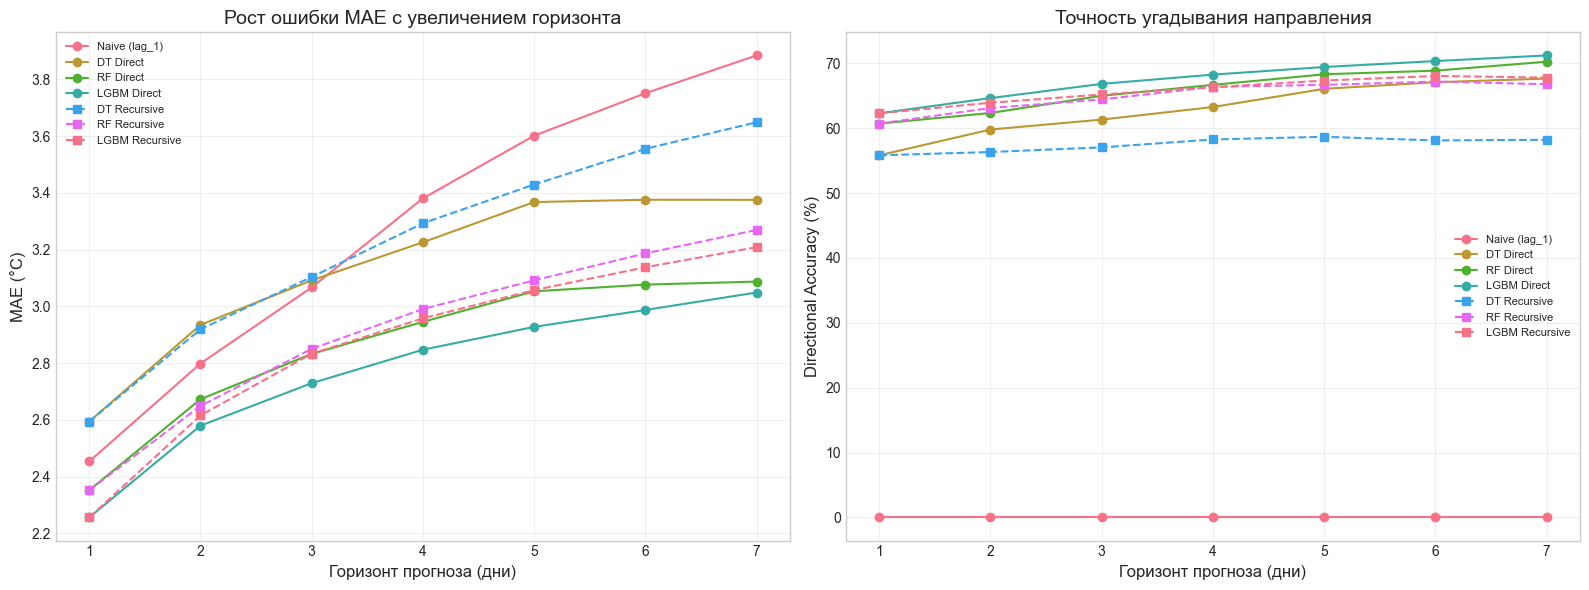

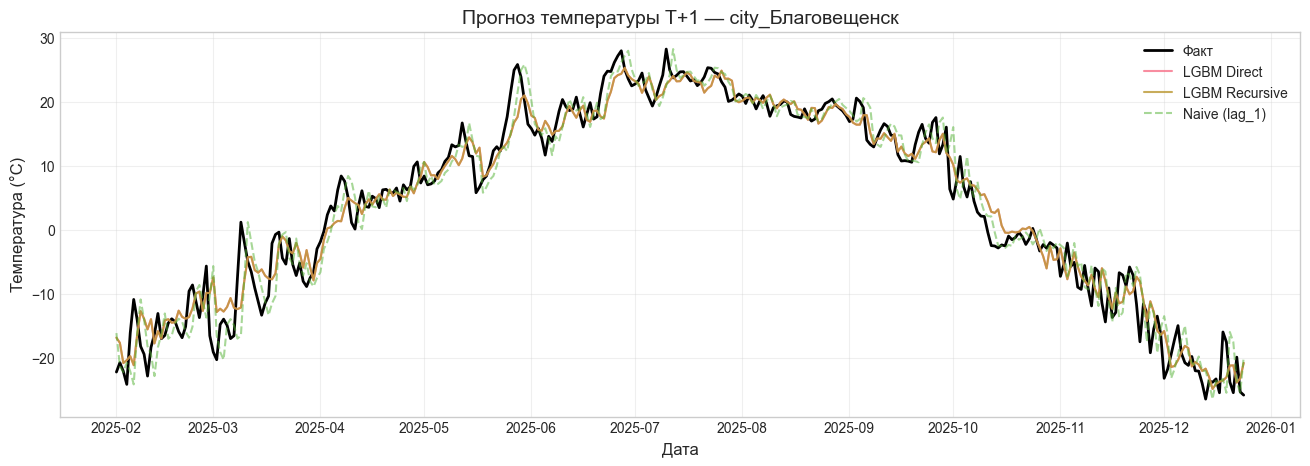

In [14]:
# 1. Рост ошибки MAE по горизонтам
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for model_name in ['Naive (lag_1)', 'DT Direct', 'RF Direct', 'LGBM Direct', 
                     'DT Recursive', 'RF Recursive', 'LGBM Recursive']:
    subset = results_df[results_df['Model'] == model_name]
    linestyle = '--' if 'Recursive' in model_name else '-'
    marker = 'o' if 'Direct' in model_name or 'Naive' in model_name else 's'
    axes[0].plot(subset['Horizon'], subset['MAE'], marker=marker, linestyle=linestyle, label=model_name)

axes[0].set_xlabel('Горизонт прогноза (дни)')
axes[0].set_ylabel('MAE (°C)')
axes[0].set_title('Рост ошибки MAE с увеличением горизонта')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

for model_name in ['Naive (lag_1)', 'DT Direct', 'RF Direct', 'LGBM Direct', 
                     'DT Recursive', 'RF Recursive', 'LGBM Recursive']:
    subset = results_df[results_df['Model'] == model_name]
    linestyle = '--' if 'Recursive' in model_name else '-'
    marker = 'o' if 'Direct' in model_name or 'Naive' in model_name else 's'
    axes[1].plot(subset['Horizon'], subset['DirAcc (%)'], marker=marker, linestyle=linestyle, label=model_name)

axes[1].set_xlabel('Горизонт прогноза (дни)')
axes[1].set_ylabel('Directional Accuracy (%)')
axes[1].set_title('Точность угадывания направления')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Прогноз vs Факт для одного города
city_col = [c for c in test.columns if c.startswith('city_')][0]
mask = test[city_col] == 1

h_plot = 1  # Горизонт для отрисовки
y_true_plot = test[f'target_h{h_plot}'].values[mask]
y_lgbm_direct = direct_lgb[h_plot].predict(test[features])[mask]
y_lgbm_recursive = lgb_recursive_preds[:, h_plot-1][mask]
y_naive = test['temp_lag_1'].values[mask]
dates_plot = test['ds'].values[mask]

plt.figure(figsize=(16, 5))
plt.plot(dates_plot, y_true_plot, label='Факт', color='black', linewidth=2)
plt.plot(dates_plot, y_lgbm_direct, label='LGBM Direct', alpha=0.8)
plt.plot(dates_plot, y_lgbm_recursive, label='LGBM Recursive', alpha=0.8)
plt.plot(dates_plot, y_naive, label='Naive (lag_1)', alpha=0.5, linestyle='--')
plt.title(f'Прогноз температуры T+{h_plot} — {city_col}')
plt.xlabel('Дата')
plt.ylabel('Температура (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 13. Анализ остатков (Residual Analysis)

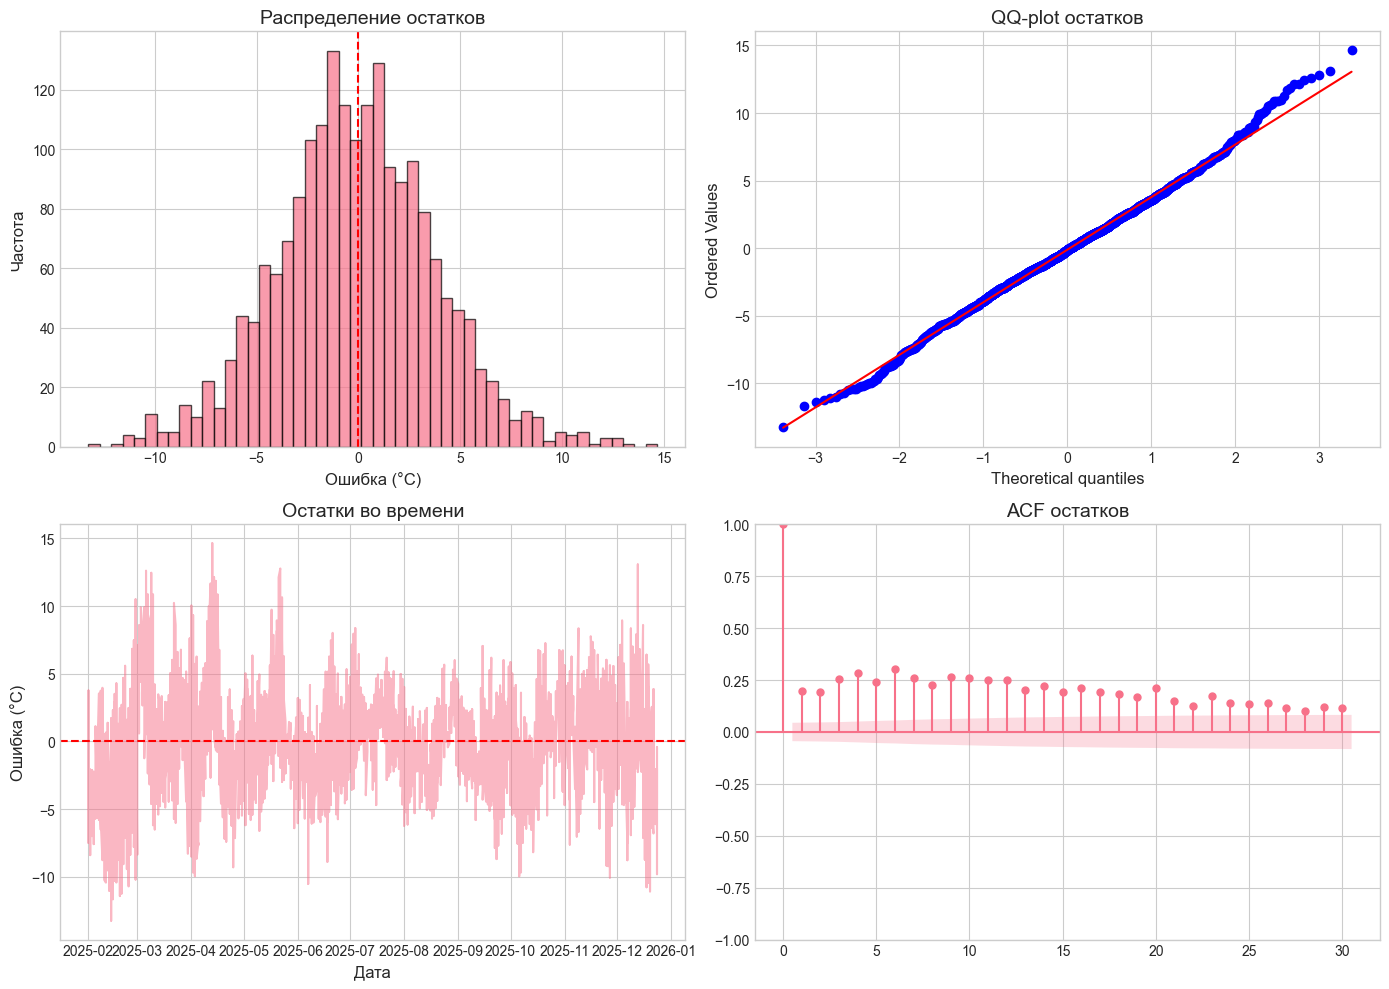

Среднее остатков:  -0.1243 (≈0 — хорошо)
Ст. отклонение:    3.8908
Минимум:           -13.2503
Максимум:          14.6504
Тест Шапиро-Уилка: p-value = 0.001335
Остатки НЕ нормальны


In [15]:
y_true_h7 = test['target_h7'].values
y_pred_h7 = direct_lgb[7].predict(test[features])
residuals = y_true_h7 - y_pred_h7

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Распределение остатков
axes[0, 0].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(x=0, color='red', linestyle='--')
axes[0, 0].set_title('Распределение остатков')
axes[0, 0].set_xlabel('Ошибка (°C)')
axes[0, 0].set_ylabel('Частота')

# 2. QQ-plot (проверка на нормальность)
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('QQ-plot остатков')

# 3. Остатки во времени
axes[1, 0].plot(test['ds'].values, residuals, alpha=0.5)
axes[1, 0].axhline(y=0, color='red', linestyle='--')
axes[1, 0].set_title('Остатки во времени')
axes[1, 0].set_xlabel('Дата')
axes[1, 0].set_ylabel('Ошибка (°C)')

# 4. ACF остатков
plot_acf(residuals, lags=30, ax=axes[1, 1])
axes[1, 1].set_title('ACF остатков')

plt.tight_layout()
plt.show()

# Статистика остатков
print(f"Среднее остатков:  {np.mean(residuals):.4f} (≈0 — хорошо)")
print(f"Ст. отклонение:    {np.std(residuals):.4f}")
print(f"Минимум:           {np.min(residuals):.4f}")
print(f"Максимум:          {np.max(residuals):.4f}")

# Тест на нормальность (Шапиро-Уилк)
if len(residuals) > 5000:
    sample = residuals[:5000]
else:
    sample = residuals
shapiro_stat, shapiro_p = stats.shapiro(sample)
print(f"Тест Шапиро-Уилка: p-value = {shapiro_p:.6f}")
if shapiro_p > 0.05:
    print("Остатки приближены к нормальным распределению")
else:
    print("Остатки НЕ нормальны")   

## 14. Рейтинг моеделей

In [16]:
summary = results_df.groupby('Model')[['MAE', 'RMSE', 'WAPE (%)', 'DirAcc (%)', 'R2']].mean()
summary = summary.sort_values('MAE')


# Лучшая и худшая модели
best_model = summary.index[0]
worst_model = summary.index[-1]

# Проверка наличия baseline
if 'Naive (lag_1)' in summary.index:
    naive_mae = summary.loc['Naive (lag_1)', 'MAE']
else:
    naive_mae = None

best_mae = summary.loc[best_model, 'MAE']

if naive_mae is not None:
    improvement = ((naive_mae - best_mae) / naive_mae) * 100
else:
    improvement = None

# Direct vs Recursive (LightGBM)
direct_avg_mae = results_df[results_df['Model'] == 'LGBM Direct']['MAE'].mean()
recursive_avg_mae = results_df[results_df['Model'] == 'LGBM Recursive']['MAE'].mean()

print(f"""
1. Лучшая модель: {best_model}
   Средний MAE: {best_mae:.3f} °C

2. Худшая модель: {worst_model}
   Средний MAE: {summary.loc[worst_model, 'MAE']:.3f} °C
""")

if naive_mae is not None:
    print(f"""
3. Сравнение с Naive Baseline:
   Naive MAE: {naive_mae:.3f} °C
   Улучшение лучшей модели: {improvement:.1f} %
""")

print(f"""
4. Direct vs Recursive (LightGBM):
   Direct:    {direct_avg_mae:.3f} °C
   Recursive: {recursive_avg_mae:.3f} °C
   Direct {'лучше' if direct_avg_mae < recursive_avg_mae else 'хуже'} на {abs(direct_avg_mae - recursive_avg_mae):.3f} °C

""")


1. Лучшая модель: LGBM Direct
   Средний MAE: 2.768 °C

2. Худшая модель: Naive (lag_1)
   Средний MAE: 3.277 °C


3. Сравнение с Naive Baseline:
   Naive MAE: 3.277 °C
   Улучшение лучшей модели: 15.5 %


4. Direct vs Recursive (LightGBM):
   Direct:    2.768 °C
   Recursive: 2.867 °C
   Direct лучше на 0.099 °C




## 15. Итоговый отчет

### 1. Описание и первичный анализ данных
- Датасет weather_data.xlsx содержал информацию на нескольких листах, включая скрытые и технические. С помощью openpyxl были извлечены все листы. 
- Проведена фильтрация: выбраны только те 3 листа, где присутствовал целевой признак temperature_2m. Пустые строки и столбцы были удалены.
- В сырых данных присутствовали серьезные проблемы ручного ввода: искажения кодировки (кракозябры вида Áëàãîâåùåíñê) и многочисленные опечатки в названиях городов (например, мосва, геленджикк). 
- Данные проблемы были устранены с помощью функции декодирования (latin1 -> cp1251) и словаря жесткого маппинга. 
- Итоговый очищенный датафрейм составил более 370 тыс. строк.

### 2. Разведочный анализ данных (EDA)
- Был проведен визуальный анализ рядов. Вектор температуры продемонстрировал четко выраженную годовую сезонность.
- Анализ стационарности с помощью теста Дики-Фуллера (ADF) показал p−value < 0.05, что формально говорит о стационарности ряда, однако это является следствием длинной выборки (множество повторяющихся годовых циклов).
- Аддитивная декомпозиция наглядно отделила годовую сезонность от глобального тренда. Анализ ACF и PACF подтвердил высокую значимость первых лагов (зависимость от предыдущих дней) и мощную корреляцию на лаге 365 (год).

### 3. Предобработка данных
- Данные были сгруппированы по городам и приведены к единой дневной частоте (resample('D')) путем усреднения показателей.
- Для целевой переменной temperature_2m была проведена очистка от аномалий методом межквартильного размаха (IQR с коэффициентом 1.5). Было найдено и удалено 7 жестких выбросов (например, экстремальные заморозки).
- Образовавшиеся после удаления выбросов и ресемплинга пропуски были заполнены линейной интерполяцией внутри каждого города, что сохранило непрерывность рядов.

### 4. Feature engineering и выбор признаков
- Был реализован продвинутый пайплайн генерации признаков (Feature Engineering), включающий в себя создание 48 предикторов.
- Были сгенерированы: базовые календарные признаки:
    1. Фурье-гармоники для описания сложной сезонности
    2. Лаги целевой переменной (краткосрочная память на 1..14 дней)
    3. Годовой лаг (прошлогодняя температура). 
- Добавлены оконные статистики (скользящие среднее и стандартное отклонение за 7 и 30 дней) для улавливания микротрендов и волатильности.
- Введены нелинейные признаки взаимодействий: комбинация температуры и влажности (ощущаемая температура), а также градиент давления. 
- Для применения стратегии многошагового прогноза (Direct) сгенерировано 7 целевых переменных (target_h1..h7).
- Категориальный признак "город" закодирован через One-Hot Encoding.

### 5. Разбиение на выборки и предотвращение утечки
- Во избежание заглядывания в будущее (data leakage), характерного для временных рядов, разбиение было произведено строго хронологически.
- Сортированный по дате датасет был разделен в пропорции 70% / 15% / 15% (Train: 2020 – начало 2024, Val: до начала 2025, Test: весь 2025 год).
- Признаки, требующие сдвигов (lag_365) генерировали NaN в начале датасета, которые были корректно удалены до разбиения. 
- Предотвращены пересечения между выборками.

### 6. Модели и стратегии прогнозирования
- Для решения задачи многошагового прогнозирования температуры на 7 дней вперед использовались следующие алгоритмы:
    1. Decision Tree 
    2. Random Forest
    3. Градиентный бустинг (LightGBM)
- Были реализованы и протестированы две архитектурные стратегии:
    1. Direct Strategy: Обучение 7 независимых моделей, каждая из которых предсказывает свой горизонт (h=1, h=2 ... h=7).
    2. Recursive Strategy: Обучение одной модели на прогноз 1-го дня (h=1), предсказания которой затем итеративно подставляются в признаки (lags) для прогнозирования последующих дней.
- В качестве метрики базового уровня (Naive Baseline) использовалось наивное предположение: «температура завтра равна температуре сегодня».

### 7. Настройка гиперпараметров (Optuna)
- Поиск оптимальной конфигурации для LightGBM проводился с помощью фреймворка Optuna. 
- Целевой метрикой для минимизации стало среднее значение MAE по всем 7 горизонтам прогнозирования на валидационной выборке. 
- Были подобраны количество деревьев, глубина, learning_rate и параметры регуляризации деревьев.

### 8. Метрики и оценка качества
- Модели оценивались на тестовой выборке по массиву метрик: MAE, RMSE, WAPE, Directional Accuracy (точность угадывания направления изменения) и R2.
- Анализ показал, что LightGBM Direct Strategy оказался лучшим алгоритмом (средний MAE = 2.768 °C), превзойдя Naive Baseline (MAE = 3.277 °C) на 15.5%. 
- Графики зависимости ошибки от горизонта показали ожидаемый тренд: на 1-2 день прогноз очень точен (R2 > 0.92, DirAcc > 60%), но к 7-му дню ошибка (MAE) плавно возрастает, а точность угадывания направления падает, так как неопределенность погоды увеличивается. 
- Direct Strategy на доли градуса, но стабильно превосходила Recursive Strategy за счет отсутствия эффекта накопления ошибки авторегрессии.

### 9. Анализ остатков
- Для лучшей модели был проведен Residual Analysis на горизонте 7 дней. Гистограмма остатков визуально близка к колоколообразной форме со средним значением около нуля (−0.124 °C — модель не имеет сильного смещения).
- QQ‑plot показывает хорошее соответствие нормальному распределению в центральной части. На краях наблюдается небольшое отклонение от идеальной прямой: верхние квантили располагаются немного выше линии, а нижние — немного ниже, однако в самых крайних точках значения снова приближаются к теоретической линии. Такая форма отклонения свидетельствует не о тяжёлых хвостах, а скорее о лёгкой нелинейности или умеренной асимметрии в распределении ошибок.
- Тест Шапиро–Уилка формально отвергает гипотезу нормальности (что типично для больших выборок), однако визуальный анализ показывает, что отклонения от нормального распределения носят умеренный характер и не критичны для моделей на основе деревьев и градиентного бустинга.
- График автокорреляции остатков (ACF) показал, что модель уловила большинство зависимостей, хотя небольшие корреляции на первых лагах еще остаются.

### 10. Выводы
- В ходе лабораторной работы пройден полный цикл моделирования многомерных временных рядов на "грязных" Excel-данных.
- Практика показала важность тщательной ручной очистки (кодировки, опечатки) и правильного, хронологически корректного разбиения на выборки.
- Feature engineering (особенно введение лагов и оконных статистик) оказался ключевым фактором успеха.
- Эксперимент с многошаговым прогнозом продемонстрировал, что градиентный бустинг в сочетании со стратегией Direct лучше всего справляется с предсказанием погоды, так как независимые модели на каждый день горизонта не накапливают ошибку обратной связи. 
- Тем не менее, предел предсказуемости погодных рядов очевиден — ошибка неизбежно растет с увеличением горизонта прогноза. 
- Полученный пайплайн полностью воспроизводим и может быть расширен добавлением экзогенных признаков.